# r/losangeles

#### Reddit group description:

### Topic Modeling

In [1]:
import pandas as pd
import re
import gensim
import pyLDAvis
import pyLDAvis.gensim_models
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/admin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# Load and examine data
df = pd.read_csv('Data/reddit/losangeles.csv')
print(f"Loaded {len(df)} comments")
print(f"Columns: {df.columns.tolist()}")
print(f"First few comments:")
for i in range(3):
    print(f"{i+1}: {df.iloc[i, 0][:100]}...")

Loaded 34158 comments
Columns: ['0']
First few comments:
1: Yacht registered in the Cayman Islands docks in Marina del Ray....
2: With the LAX/Metro Center opening this weekend, let talk platform extensions...
3: The good news is that if there is overcrowding, Metro can instantly double capacity by increasing tr...


In [3]:
# Clean and prepare text
def clean_text(text):
    if not isinstance(text, str) or text in ['[deleted]', '[removed]', '']:
        return ""
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation, numbers, etc.
    text = re.sub(r"[^A-Za-z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

# Apply cleaning
comments = df.iloc[:, 0].apply(clean_text)
comments = comments[comments.str.len() > 10]  # Remove very short comments
print(f"After cleaning: {len(comments)} comments")

# Tokenize and remove stopwords
swords = stopwords.words('english')

# Remove punctuation from stopwords to match your cleaned text
swords_clean = []
for word in swords:
    # Apply same cleaning as clean_text function
    clean_word = re.sub(r"[^A-Za-z\s]", "", word)
    if clean_word and len(clean_word) > 0:
        swords_clean.append(clean_word.lower())

# Remove duplicates and empty strings
swords_clean = list(set([word for word in swords_clean if word]))
swords_clean = sorted(swords_clean)

print(f"Original stopwords: {len(swords)}")
# print(swords)
print(f"Cleaned stopwords: {len(swords_clean)}")
# print(swords_clean)

# Add specific stopwords
reddit_stopwords = ['reddit', 'edit', 'update', 'deleted', 'removed', 'comment', 'post', 'thread']
additional_stopwords = ['lets', 'thats', 'people', 'even', 'time', 'way', 'thats', 'youre', 'much', 
                        'would', 'could', 'get', 'one', 'also', 'really', 'think', 'know', 'like']

swords_clean.extend(reddit_stopwords + additional_stopwords)

print(f"Extended stopwords: {len(swords_clean)}")
# print(swords_clean)

# Tokenize
wordlists = []
for comment in comments:
    words = [word for word in word_tokenize(comment.lower()) 
            if word not in swords_clean 
            and len(word) > 0
            and word.isalpha()]
    
    wordlists.append(words)

print(f"Prepared {len(wordlists)} comments for modeling")

After cleaning: 32508 comments
Original stopwords: 198
Cleaned stopwords: 196
Extended stopwords: 222
Prepared 32508 comments for modeling


In [4]:
# Analyze word frequencies
all_words = [word for wordlist in wordlists for word in wordlist]
word_freq = Counter(all_words)

print("Top 20 most common words:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

Top 20 most common words:
la: 3196
city: 2314
go: 1694
good: 1563
going: 1544
see: 1473
want: 1451
housing: 1449
make: 1423
need: 1414
years: 1299
still: 1276
got: 1217
back: 1188
right: 1185
work: 1156
car: 1127
lot: 1117
new: 1110
homeless: 1081


In [5]:
# Run topic model
def run_topic_model(wordlists, num_topics=4, alpha=0.7, eta=0.5):
    dictionary = gensim.corpora.Dictionary(wordlists)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(wl) for wl in wordlists]
    
    model = gensim.models.LdaMulticore(
        corpus, 
        id2word=dictionary, 
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        random_state=1
    )
    
    return model, corpus, dictionary

# Run the model
model, corpus, dictionary = run_topic_model(wordlists, num_topics=4)

# Display topics
print("Topics found:")
print("=" * 50)

for idx, topic in model.show_topics(formatted=False, num_words=10):
    print(f"\nTopic {idx + 1}:")
    words = [word for word, prob in topic]
    print(f"{', '.join(words)}")

# Visualize topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(model, corpus, dictionary)
vis

Topics found:

Topic 1:
la, city, go, got, make, good, years, housing, want, cant

Topic 2:
la, good, go, city, want, still, see, going, make, got

Topic 3:
la, city, see, need, housing, make, go, back, live, going

Topic 4:
la, city, going, work, good, go, housing, many, need, right


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.007078  0.003257       1        1  30.300294
0      0.003224  0.000742       2        1  23.720101
2     -0.001739 -0.005868       3        1  23.333241
1      0.005593  0.001869       4        1  22.646363, topic_info=         Term         Freq        Total Category  logprob  loglift
155   parking   641.000000   641.000000  Default  30.0000  30.0000
141    please   531.000000   531.000000  Default  29.0000  29.0000
62         la  2951.000000  2951.000000  Default  28.0000  28.0000
223       got  1117.000000  1117.000000  Default  27.0000  27.0000
7619    chips   251.000000   251.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
183      cant   213.343418  1013.761237   Topic4  -6.1593  -0.0733
469        us   198.687587   955.650602   Topic4  -6.2305  -0.0855
724       say   186.491129   812.161776   Topic4  -6.2938   0.0139
90       live   188.490753   937.172921   Topic4  -6.2831  -0.1186
79     around   187.884904   965.868959   Topic4  -6.2864  -0.1520

[370 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
233       1  0.153344  abide
233       2  0.318484  abide
233       3  0.141548  abide
233       4  0.389258  abide
749       1  0.259714   able
...     ...       ...    ...
60        4  0.214439  years
439       1  0.297301    yes
439       2  0.294414    yes
439       3  0.238129    yes
439       4  0.168855    yes

[1052 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 3, 2])

### Sentiment Analysis

In [6]:
# Sentiment Analysis for Reddit Comments
from textblob import TextBlob
import pandas as pd

# Apply sentiment analysis to your cleaned comments
print("Analyzing sentiment...")
sentiment_scores = [TextBlob(comment).sentiment.polarity for comment in comments]

# Create dataframe with comments and polarity scores
df_sentiment = pd.DataFrame({
    'comment': comments,
    'polarity': sentiment_scores
})

print(f"Analyzed {len(df_sentiment)} comments")
print(f"Sentiment analysis complete!")

# Display basic statistics
print(f"\nSentiment Statistics:")
print(f"Mean polarity: {df_sentiment['polarity'].mean():.3f}")
print(f"Median polarity: {df_sentiment['polarity'].median():.3f}")
print(f"Min polarity: {df_sentiment['polarity'].min():.3f}")
print(f"Max polarity: {df_sentiment['polarity'].max():.3f}")

# Categorize sentiments
df_sentiment['sentiment_category'] = df_sentiment['polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print(f"\nSentiment Distribution:")
print(df_sentiment['sentiment_category'].value_counts())

# Show examples
print(f"\nMost Positive Comments:")
print(df_sentiment.nlargest(3, 'polarity')[['comment', 'polarity']])

print(f"\nMost Negative Comments:")
print(df_sentiment.nsmallest(3, 'polarity')[['comment', 'polarity']])

Analyzing sentiment...
Analyzed 32508 comments
Sentiment analysis complete!

Sentiment Statistics:
Mean polarity: 0.072
Median polarity: 0.000
Min polarity: -1.000
Max polarity: 1.000

Sentiment Distribution:
sentiment_category
Neutral     16061
Positive    11502
Negative     4945
Name: count, dtype: int64

Most Positive Comments:
                                                comment  polarity
412                   FlyAway would be your best option       1.0
657   Whats the best place to check and see how your...       1.0
1418           Can you take me hire in best Creed voice       1.0

Most Negative Comments:
                                                comment  polarity
3125                                Yall are insane Nah      -1.0
3513  There was a nasty wreck at the Ralphs by Popey...      -1.0
3760  Just dont buy produce at Trader Joes whatever ...      -1.0


parking: 652 comments found
sleep: 109 comments found
bathroom: 92 comments found
water: 238 comments found
cook: 100 comments found
police: 591 comments found
noise: 83 comments found
solar: 44 comments found
job: 730 comments found


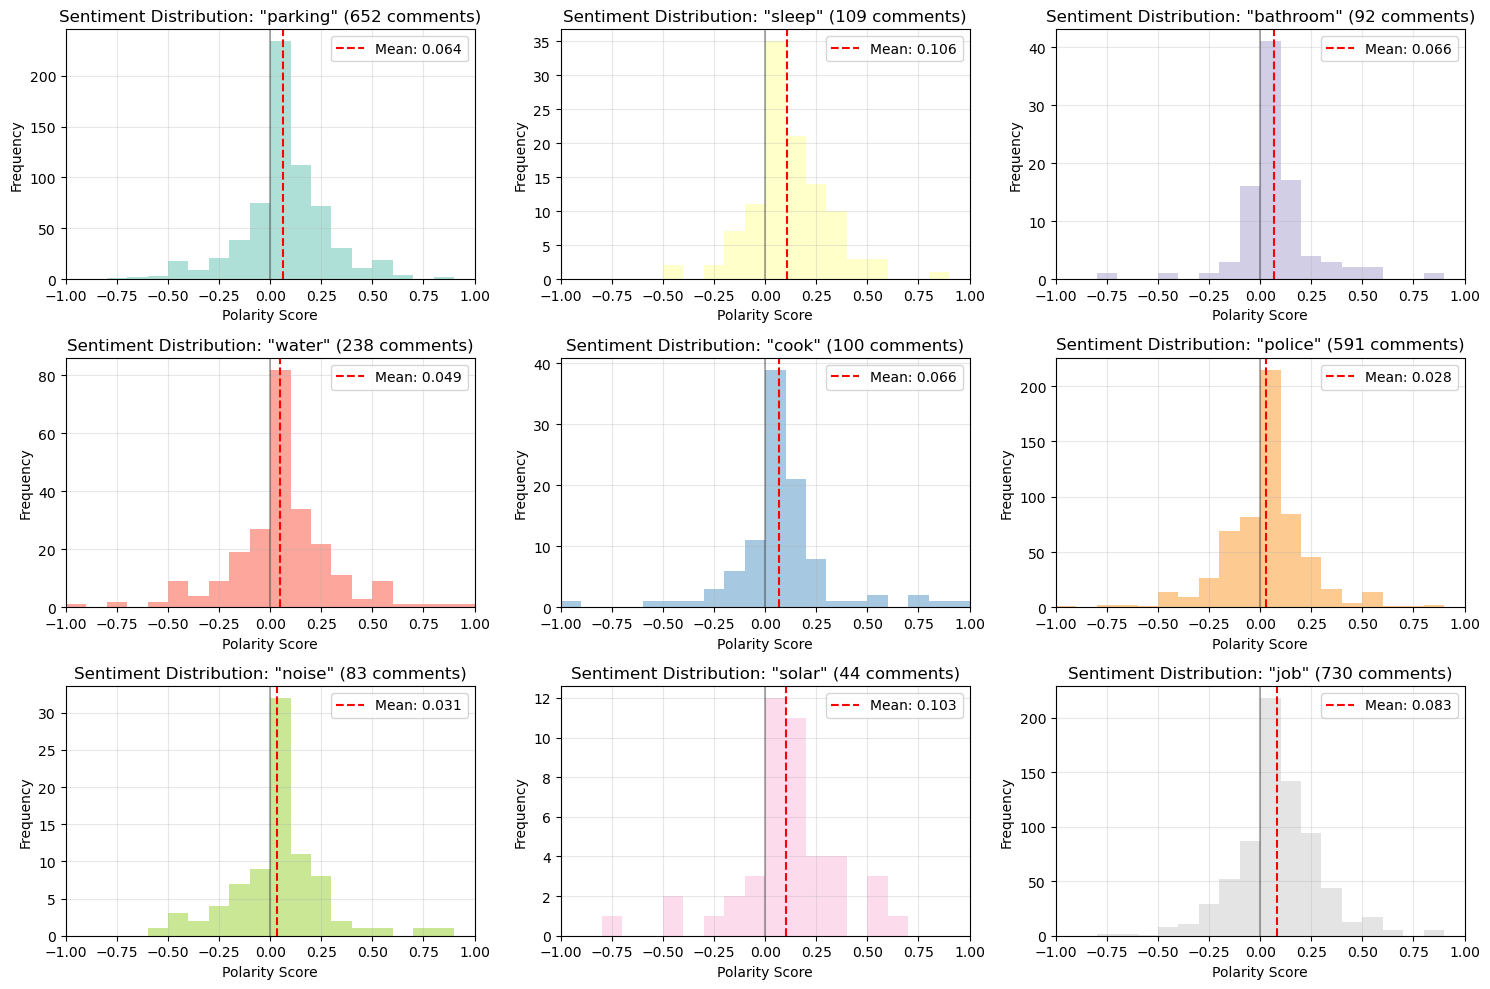

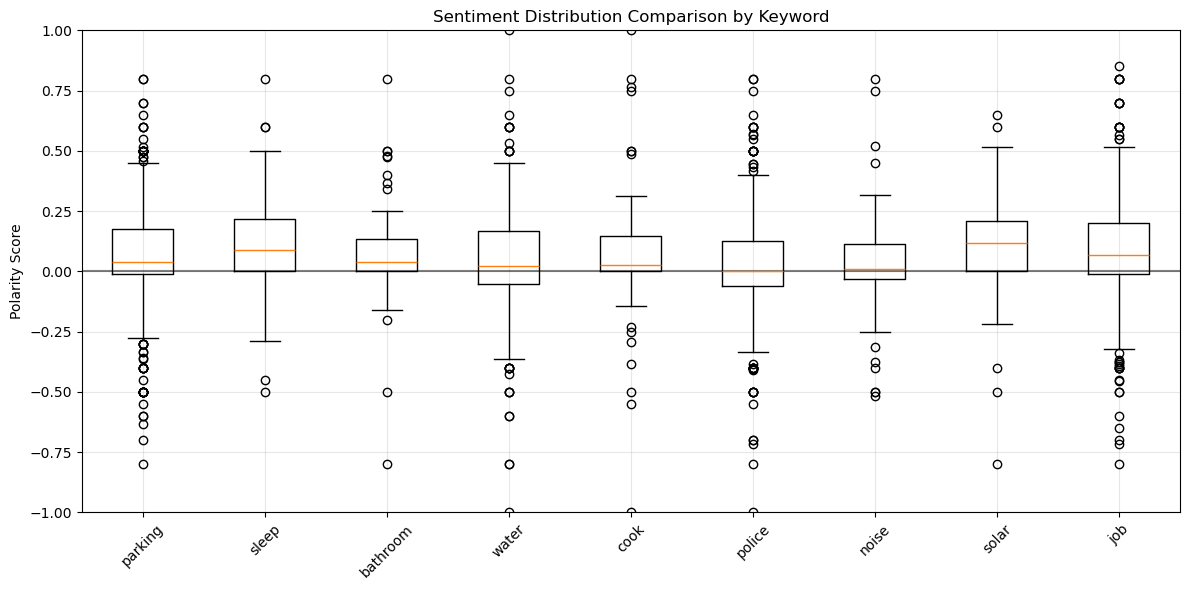

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# Define keywords to analyze
keywords = ['parking', 'sleep', 'bathroom', 'water', 'cook', 'police', 'noise', 'solar', 'job']

# Function to find comments containing specific keywords
def get_sentiment_by_keyword(df_sentiment, keyword):
    mask = df_sentiment['comment'].str.contains(keyword, case=False, na=False)
    return df_sentiment[mask]['polarity']

# Collect sentiment data for each keyword
keyword_sentiments = {}
for keyword in keywords:
    sentiments = get_sentiment_by_keyword(df_sentiment, keyword)
    keyword_sentiments[keyword] = sentiments
    print(f"{keyword}: {len(sentiments)} comments found")

# Create subplot for each keyword
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
x_min, x_max = -1.0, 1.0  
bins = np.linspace(x_min, x_max, 21)  

for i, keyword in enumerate(keywords):
    sentiments = keyword_sentiments[keyword]
    
    if len(sentiments) > 0:
        # Create histogram with consistent bins and x-axis
        axes[i].hist(sentiments, bins=bins, alpha=0.7, color=plt.cm.Set3(i))
        axes[i].axvline(sentiments.mean(), color='red', linestyle='--', 
                       label=f'Mean: {sentiments.mean():.3f}')
        axes[i].set_title(f'Sentiment Distribution: "{keyword}" ({len(sentiments)} comments)')
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')
        axes[i].set_xlim(x_min, x_max)  # Consistent x-axis range
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add vertical line at 0 for reference
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'No comments found\nfor "{keyword}"', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'Sentiment Distribution: "{keyword}"')
        axes[i].set_xlim(x_min, x_max)  # Keep same x-axis even for empty plots
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plot comparison with consistent y-axis
plt.figure(figsize=(12, 6))
sentiment_data = [keyword_sentiments[keyword] for keyword in keywords if len(keyword_sentiments[keyword]) > 0]
labels = [keyword for keyword in keywords if len(keyword_sentiments[keyword]) > 0]

if sentiment_data:
    plt.boxplot(sentiment_data, labels=labels)
    plt.title('Sentiment Distribution Comparison by Keyword')
    plt.ylabel('Polarity Score')
    plt.ylim(x_min, x_max)  
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No sentiment data found for any keywords")